# ELSA: model progression from Cox PH to Transformer

This notebook mirrors the simulation analysis using the agreed ELSA outcome set:

- **Basic Cox PH** — one separate Cox model per outcome, baseline covariates only.
- **Deep MultiCox NN** — one shared neural network with an outcome-specific Cox partial likelihood.
- **Simple binary time series** — multi-outcome discrete-time hazards with baseline covariates, fixed baseline disease-prevalence indicators, and interval-specific baseline hazards.
- **Transformer** — the same discrete-time multi-outcome hazard target, with baseline covariates plus causal attention over evolving prior disease history (`prev_*`).

Death is the final absorbing state. Prevalent disease at study entry is history, not an incident event.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import importlib, sys
# Force reload the module
for m in ("prepare_elsa_models", "elsa_model_definitions"):
    if m in sys.modules: importlib.reload(sys.modules[m])
        
from prepare_elsa_models import (
    EVENT_TYPES,
    DISEASE_EVENTS,
    COVARIATE_COLS,
    PREVALENCE_COLS,
    BINARY_COVARIATE_COLS,
    HISTORY_COLS,
    prepare_elsa_wide,
    make_simple_binary_timeseries,
    make_transformer,
)

from elsa_model_definitions import (
    split_ids,
    fit_separate_coxph,
    score_separate_coxph,
    cox_coefficient_table,
    fit_multicox_nn,
    score_multicox_nn,
    fit_simple_binary,
    score_simple_binary_baseline,
    fit_transformer,
    score_transformer_at_baseline,
    dynamic_cindex_table,
    cindex_table_from_scores,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

EVENT_TYPES


['cvd',
 'stroke',
 'hypertension',
 'diabetes',
 'asthma_respir',
 'cancer',
 'arthritis',
 'osteo_hip',
 'mental_health',
 'neuro',
 'cataract',
 'death']

## 1. Load and shape ELSA

Set `file_elsa` to the preprocessed ELSA file produced by the R pipeline. The adapter accepts CSV, pickle, parquet, feather and Excel.

The baseline covariates are fixed to **age, BMI, sex, education and wealth**. Ethnicity is excluded, and hypertension is an outcome rather than a baseline covariate.


In [4]:
# EDIT THIS PATH
file_elsa = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/elsa_data.csv"

wide = prepare_elsa_wide(file_elsa, bmi_col= "bmi_latest")

print("N =", len(wide))
print("Cox/MultiCox covariates:", COVARIATE_COLS)
print("Binary covariates:", BINARY_COVARIATE_COLS)
print("Transformer history:", HISTORY_COLS)
print("Outcomes:", EVENT_TYPES)
wide.head()


time-varying BMI available from waves [2, 4, 6, 8]
N = 15137
Cox/MultiCox covariates: ['age', 'bmi', 'sex', 'edu', 'wealth']
Binary covariates: ['age', 'bmi', 'sex', 'edu', 'wealth', 'prevalent_cvd', 'prevalent_stroke', 'prevalent_hypertension', 'prevalent_diabetes', 'prevalent_asthma_respir', 'prevalent_cancer', 'prevalent_arthritis', 'prevalent_osteo_hip', 'prevalent_mental_health', 'prevalent_neuro', 'prevalent_cataract']
Transformer history: ['prev_cvd', 'prev_stroke', 'prev_hypertension', 'prev_diabetes', 'prev_asthma_respir', 'prev_cancer', 'prev_arthritis', 'prev_osteo_hip', 'prev_mental_health', 'prev_neuro', 'prev_cataract']
Outcomes: ['cvd', 'stroke', 'hypertension', 'diabetes', 'asthma_respir', 'cancer', 'arthritis', 'osteo_hip', 'mental_health', 'neuro', 'cataract', 'death']


,id,age,bmi,sex,edu,wealth,exit_dis,exit_death,bmi_w2,bmi_t2,...,event_neuro,time_neuro,age_cataract,prevalent_cataract,event_cataract,time_cataract,age_death,prevalent_death,event_death,time_death
0,100001,53.75,30.405910,0,1,1.000000,64.33,64.33,NaN,0.000,...,0,10.58,NaN,0,0,10.58,NaN,0,0,10.58
1,100005,64.42,25.019214,0,1,2.500000,72.08,72.08,NaN,-6.453,...,0,7.66,NaN,0,0,7.66,NaN,0,0,7.66
2,100006,58.08,32.400002,0,1,2.333333,61.92,61.92,NaN,-4.113,...,0,3.84,NaN,0,0,3.84,NaN,0,0,3.84
3,100007,57.00,28.610956,0,1,2.625000,71.00,71.00,NaN,0.000,...,0,14.00,62.25,0,1,5.25,NaN,0,0,14.00
4,100009,66.58,31.200001,0,1,3.166667,78.75,78.75,NaN,-1.613,...,0,12.17,NaN,0,0,12.17,NaN,0,0,12.17


In [5]:
# Basic data audit
audit = []
for e in EVENT_TYPES:
    audit.append({
        "event": e,
        "prevalent_n": int(wide[f"prevalent_{e}"].sum()),
        "incident_n": int(wide[f"event_{e}"].sum()),
        "incident_pct_all": 100 * wide[f"event_{e}"].mean(),
        "median_followup_y": wide.loc[wide[f"prevalent_{e}"] == 0, f"time_{e}"].median(),
    })

audit = pd.DataFrame(audit)
audit


,event,prevalent_n,incident_n,incident_pct_all,median_followup_y
0,cvd,2256,2202,14.547136,9.58
1,stroke,468,699,4.617824,10.08
2,hypertension,4728,2664,17.599260,7.92
3,diabetes,1042,1111,7.339631,9.92
4,asthma_respir,2052,1012,6.685605,9.92
5,cancer,872,1301,8.594834,9.91
6,arthritis,4320,2319,15.320077,8.25
7,osteo_hip,608,1316,8.693929,9.92
8,mental_health,1081,756,4.994385,10.00
9,neuro,125,439,2.900178,10.08


,Overall,Male,Female
Characteristic,,,
N,"15,137","6,849","8,288"
,,,
"Age at entry, mean (SD)",62.2 (9.8),62.5 (9.3),62.0 (10.2)
"BMI, mean (SD)",28.2 (5.0),28.2 (4.4),28.2 (5.5)
"Female, n (%)","8,288 (54.8)",0 (0.0),"8,288 (100.0)"
"Education, median (IQR)",2.0 (1.0-2.0),2.0 (1.0-2.0),2.0 (1.0-2.0)
"Wealth quintile, median (IQR)",3.0 (2.0-4.0),3.0 (2.0-4.1),2.9 (1.9-4.0)
,,,
"Follow-up (y), median (IQR)",10.1 (5.8-15.8),10.0 (5.4-14.5),10.2 (6.0-15.9)


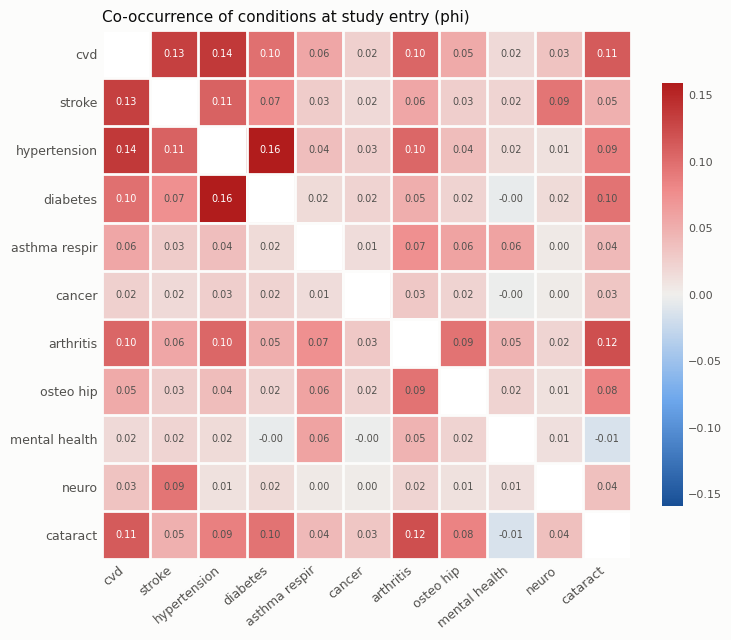

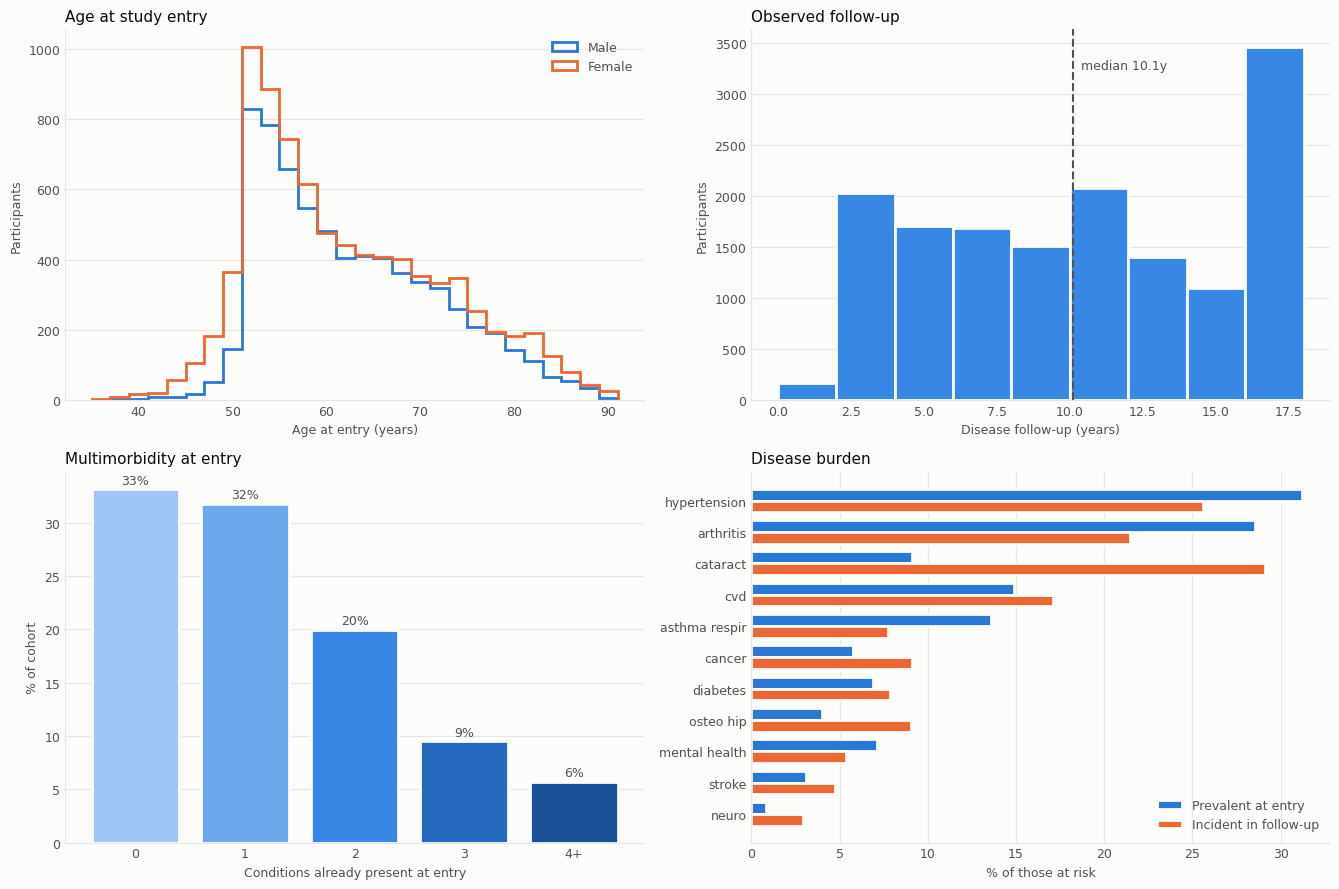

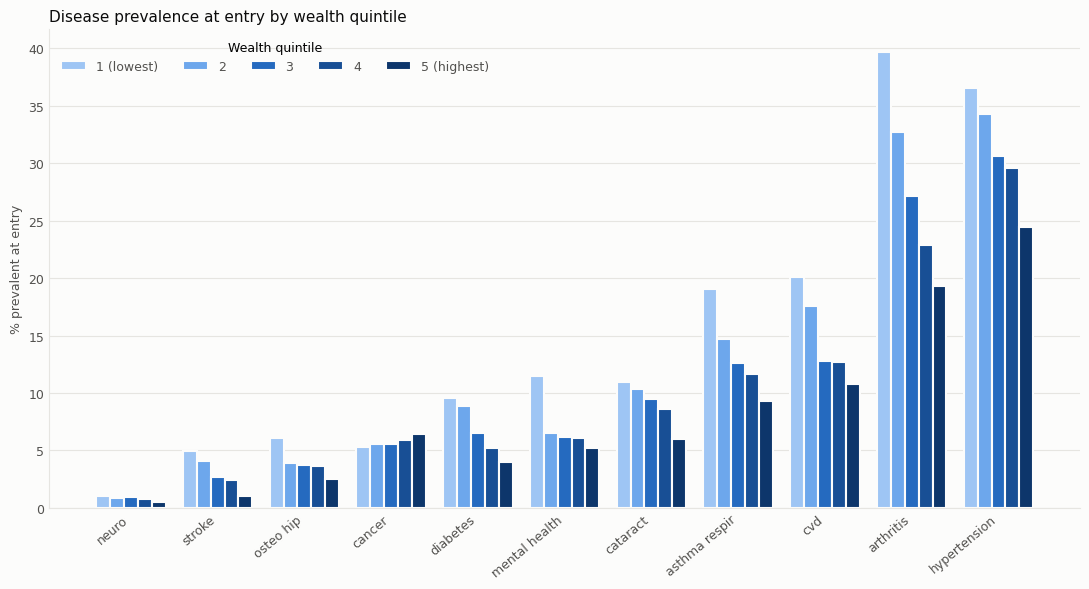

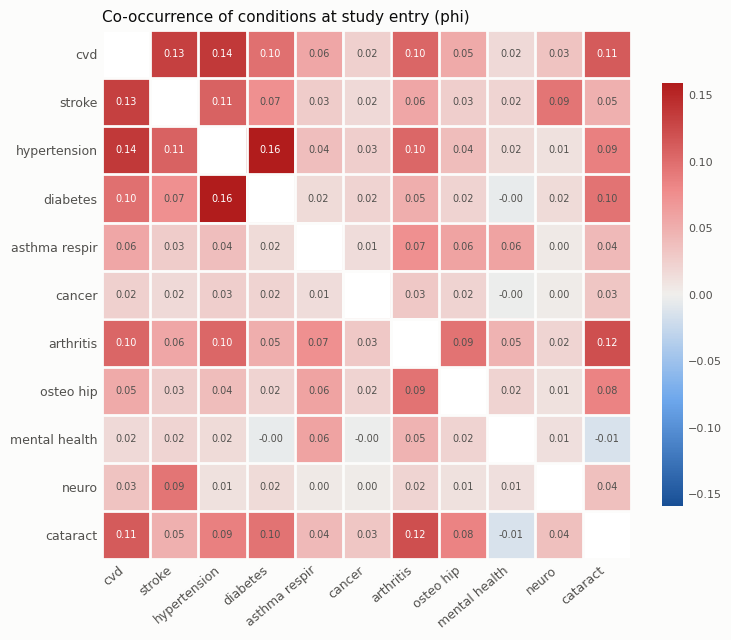

In [6]:
import importlib
from elsa_describe import table1, plot_cohort, plot_burden_by_group, plot_cooccurrence

t1 = table1(wide, EVENT_TYPES, by="sex")        # by=None, "sex", "wealth", "edu"
display(t1)
t1.to_csv("elsa_table1.csv")

plot_cohort(wide, EVENT_TYPES)
plot_burden_by_group(wide, EVENT_TYPES, group="wealth", group_name="Wealth quintile")
plot_cooccurrence(wide, EVENT_TYPES)

## 2. Patient-level train/test split

Every model uses the **same people** in training and testing. This is important because the discrete-time data contain multiple rows per person; splitting rows would leak the same participant into both sets.


In [8]:
train_ids, test_ids = split_ids(wide["id"], test_size=0.25, seed=SEED)

train_wide = wide[wide["id"].isin(train_ids)].copy().reset_index(drop=True)
test_wide = wide[wide["id"].isin(test_ids)].copy().reset_index(drop=True)

print("Train:", len(train_wide))
print("Test :", len(test_wide))


Train: 11353
Test : 3784


## 3. Basic Cox PH — separate model for each outcome

Each outcome has its own risk set. Someone with prevalent arthritis is excluded from the arthritis Cox model but can still contribute to the diabetes, cancer, stroke, etc. models if those conditions were not prevalent at entry.


In [10]:
cox_models = fit_separate_coxph(
    train_wide,
    covariates=COVARIATE_COLS,
    event_types=EVENT_TYPES,
)

cox_scores = score_separate_coxph(
    cox_models,
    test_wide,
    covariates=COVARIATE_COLS,
    event_types=EVENT_TYPES,
)

cox_results = cindex_table_from_scores(
    test_wide,
    cox_scores,
    EVENT_TYPES,
    model_name="Basic Cox",
)

cox_results


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Basic Cox,3186,549,0.639531
1,stroke,Basic Cox,3663,159,0.719726
2,hypertension,Basic Cox,2577,668,0.588654
3,diabetes,Basic Cox,3518,265,0.674689
4,asthma_respir,Basic Cox,3251,265,0.610911
5,cancer,Basic Cox,3569,328,0.592848
6,arthritis,Basic Cox,2707,558,0.610357
7,osteo_hip,Basic Cox,3612,297,0.721481
8,mental_health,Basic Cox,3517,185,0.632809
9,neuro,Basic Cox,3751,110,0.789680


In [11]:
# Coefficients / hazard ratios for inspection
cox_coef = cox_coefficient_table(cox_models)
cox_coef.head(20)


,event,covariate,coef,hazard_ratio,se,p
0,cvd,age,0.044246,1.045240,0.002728,3.679164e-59
1,cvd,bmi,0.027948,1.028342,0.004778,4.934256e-09
2,cvd,sex,-0.235206,0.790408,0.049851,2.379106e-06
3,cvd,edu,0.111890,1.118390,0.041572,7.114250e-03
4,cvd,wealth,-0.102433,0.902638,0.021009,1.083879e-06
5,stroke,age,0.067810,1.070162,0.004642,2.539758e-48
6,stroke,bmi,0.001793,1.001794,0.008900,8.403546e-01
7,stroke,sex,-0.315319,0.729556,0.087232,3.006775e-04
8,stroke,edu,-0.077689,0.925252,0.074850,2.993014e-01
9,stroke,wealth,-0.216000,0.805736,0.037260,6.746270e-09


## 4. Deep multi-outcome Cox NN

This is the main ELSA adaptation to the original simulation class. The original MultiCox code assumes everybody is eligible for every outcome. In ELSA that is not true because many participants have prevalent disease at entry.

Here, each outcome has its **own prevalence mask inside the Cox loss**, so we do not need to discard a participant merely because a different disease was already present.


In [13]:
multicox_model, multicox_scaler, multicox_loss = fit_multicox_nn(
    train_wide,
    covariates=COVARIATE_COLS,
    event_types=EVENT_TYPES,
    hidden_dims=(64, 32),
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=500,
    verbose_every=50,
    seed=SEED,
)

multicox_scores = score_multicox_nn(
    multicox_model,
    multicox_scaler,
    test_wide,
    COVARIATE_COLS,
)

multicox_results = cindex_table_from_scores(
    test_wide,
    multicox_scores,
    EVENT_TYPES,
    model_name="Deep MultiCox",
)

multicox_results


MultiCox eligible per outcome: cvd=9695, stroke=11006, hypertension=7832, diabetes=10577, asthma_respir=9834, cancer=10696, arthritis=8110, osteo_hip=10917, mental_health=10539, neuro=11261, cataract=10298, death=11353
MultiCox epoch    1/500: loss=8.7499
MultiCox epoch   50/500: loss=8.5698
MultiCox epoch  100/500: loss=8.5122
MultiCox epoch  150/500: loss=8.5060
MultiCox epoch  200/500: loss=8.5026
MultiCox epoch  250/500: loss=8.4966
MultiCox epoch  300/500: loss=8.4967
MultiCox epoch  350/500: loss=8.4883
MultiCox epoch  400/500: loss=8.4898
MultiCox epoch  450/500: loss=8.4875
MultiCox epoch  500/500: loss=8.4876


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Deep MultiCox,3186,549,0.643200
1,stroke,Deep MultiCox,3663,159,0.721240
2,hypertension,Deep MultiCox,2577,668,0.595260
3,diabetes,Deep MultiCox,3518,265,0.675363
4,asthma_respir,Deep MultiCox,3251,265,0.629855
5,cancer,Deep MultiCox,3569,328,0.614078
6,arthritis,Deep MultiCox,2707,558,0.604780
7,osteo_hip,Deep MultiCox,3612,297,0.726093
8,mental_health,Deep MultiCox,3517,185,0.639187
9,neuro,Deep MultiCox,3751,110,0.788389


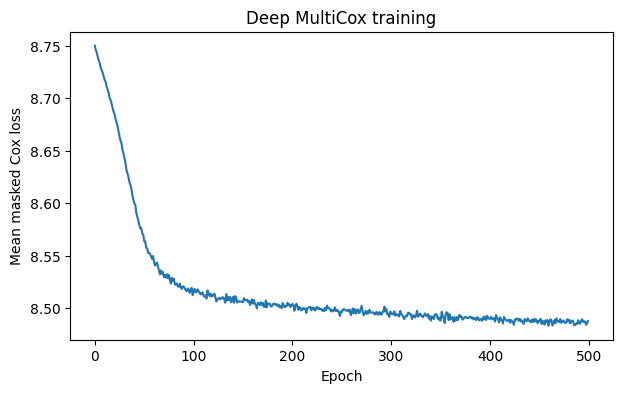

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(multicox_loss)
plt.xlabel("Epoch")
plt.ylabel("Mean masked Cox loss")
plt.title("Deep MultiCox training")
plt.show()


## 5. Simple binary time-series model

The simple binary model receives the same baseline demographic/clinical covariates as Cox/MultiCox **plus fixed disease-prevalence indicators measured at ELSA entry**.

The `prevalent_<event>` indicators are repeated unchanged across a participant's 2-year rows. The model does **not** receive newly acquired `prev_*` disease history. Post-event and non-observable rows are excluded through the outcome-specific masks.

This mirrors the simulation setup more closely while reserving evolving longitudinal disease history for the Transformer.


In [16]:
INTERVAL_YEARS = 2.0

train_long_binary, binary_features = make_simple_binary_timeseries(
    train_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=BINARY_COVARIATE_COLS,
    include_history=False,
)

test_long_binary, _ = make_simple_binary_timeseries(
    test_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=BINARY_COVARIATE_COLS,
    include_history=False,
)

print(train_long_binary.shape, test_long_binary.shape)
print("Binary features:", binary_features)

assert binary_features == BINARY_COVARIATE_COLS
assert not any(f.startswith("prev_") for f in binary_features)


(102177, 69) (34056, 69)
Binary features: ['age', 'bmi', 'sex', 'edu', 'wealth', 'prevalent_cvd', 'prevalent_stroke', 'prevalent_hypertension', 'prevalent_diabetes', 'prevalent_asthma_respir', 'prevalent_cancer', 'prevalent_arthritis', 'prevalent_osteo_hip', 'prevalent_mental_health', 'prevalent_neuro', 'prevalent_cataract']


In [17]:
binary_model, binary_scaler, binary_loss = fit_simple_binary(
    train_long_binary,
    features=binary_features,
    event_types=EVENT_TYPES,
    hidden_dims=(64, 32),
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=60,
    batch_size=512,
    verbose_every=20,
    seed=SEED,
)

binary_scores = score_simple_binary_baseline(
    binary_model,
    binary_scaler,
    test_wide,
    binary_features,
)

binary_results = cindex_table_from_scores(
    test_wide,
    binary_scores,
    EVENT_TYPES,
    model_name="Binary time series",
)

binary_results


Binary TS alpha initialised: baseline hazard 4.43e-05 - 1.51e-01, overall rate 0.0227
Binary TS null loss (constant per-event rate): 0.10282
Binary TS epoch    1/60: loss=0.0985
Binary TS epoch   20/60: loss=0.0951
Binary TS epoch   40/60: loss=0.0946
Binary TS epoch   60/60: loss=0.0945


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Binary time series,3186,549,0.638044
1,stroke,Binary time series,3663,159,0.732396
2,hypertension,Binary time series,2577,668,0.598343
3,diabetes,Binary time series,3518,265,0.683427
4,asthma_respir,Binary time series,3251,265,0.602020
5,cancer,Binary time series,3569,328,0.599846
6,arthritis,Binary time series,2707,558,0.612653
7,osteo_hip,Binary time series,3612,297,0.733598
8,mental_health,Binary time series,3517,185,0.658089
9,neuro,Binary time series,3751,110,0.783971


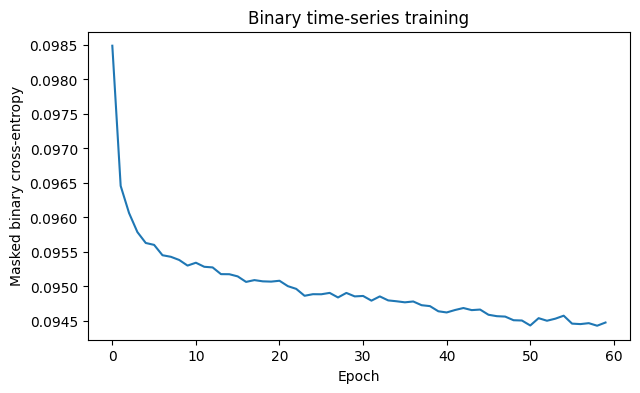

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(binary_loss)
plt.xlabel("Epoch")
plt.ylabel("Masked binary cross-entropy")
plt.title("Binary time-series training")
plt.show()


## 6. Transformer

The Transformer receives the original baseline covariates plus dynamic `prev_<event>` indicators.

At interval 0, `prev_<event>` equals disease status already prevalent at ELSA entry. At later intervals it additionally records incident disease that occurred in **earlier** intervals. The Transformer therefore has the same baseline disease-status information available to the binary model, but its disease-state inputs evolve over time.

We do **not** also include `prevalent_*` in the Transformer input because that information is already contained in `prev_*` and would be duplicated. There is no `prev_death` predictor because death is terminal.

The Transformer uses the same masked binary survival loss as the simple time-series model, with causal attention preventing future intervals from influencing earlier predictions.


In [20]:
train_long_tr, transformer_features = make_transformer(
    train_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=COVARIATE_COLS,
    include_prev_features=True,
    as_torch=False,
)

test_long_tr, _ = make_transformer(
    test_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=COVARIATE_COLS,
    include_prev_features=True,
    as_torch=False,
)

expected_transformer_features = COVARIATE_COLS + HISTORY_COLS
assert transformer_features == expected_transformer_features
assert "prev_death" not in transformer_features

# Verify that interval-0 prev_* exactly reproduces baseline prevalence.
baseline_rows = train_long_tr.loc[train_long_tr["interval"] == 0].set_index("id")
baseline_wide = train_wide.set_index("id")
for e in DISEASE_EVENTS:
    np.testing.assert_array_equal(
        baseline_rows.loc[baseline_wide.index, f"prev_{e}"].to_numpy(),
        baseline_wide[f"prevalent_{e}"].to_numpy(),
    )

print("Transformer features:")
print(transformer_features)
print("Train long:", train_long_tr.shape)


Transformer features:
['age', 'bmi', 'sex', 'edu', 'wealth', 'prev_cvd', 'prev_stroke', 'prev_hypertension', 'prev_diabetes', 'prev_asthma_respir', 'prev_cancer', 'prev_arthritis', 'prev_osteo_hip', 'prev_mental_health', 'prev_neuro', 'prev_cataract']
Train long: (102177, 58)


In [21]:
transformer_model, transformer_loss = fit_transformer(
    train_long_tr,
    features=transformer_features,
    event_types=EVENT_TYPES,
    d_model=64,
    nhead=2,
    nlayers=2,
    dropout=0.15,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=20,
    batch_size=512,
    verbose_every=5,
    seed=SEED,
)


Transformer alpha initialised: baseline hazard 4.43e-05 - 1.51e-01, overall rate 0.0227
Transformer null loss (constant per-event rate): 0.10282


C:\Users\dinab\anaconda3\envs\studio1\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Transformer epoch    1/20: loss=0.0999
Transformer epoch    5/20: loss=0.0955
Transformer epoch   10/20: loss=0.0950
Transformer epoch   15/20: loss=0.0948
Transformer epoch   20/20: loss=0.0946
Causality check passed: intervals >= 4 do not affect earlier logits.


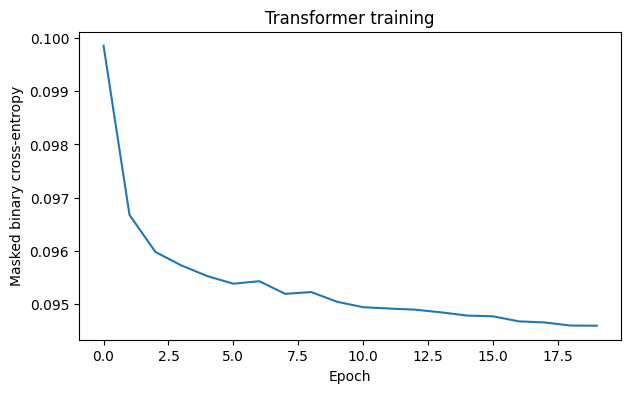

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(transformer_loss)
plt.xlabel("Epoch")
plt.ylabel("Masked binary cross-entropy")
plt.title("Transformer training")
plt.show()


### Baseline Transformer comparison

For the headline C-index comparison below, the Transformer is scored at **interval 0**.

At interval 0, its `prev_*` indicators equal baseline prevalence. The binary model receives the same baseline disease-status information through fixed `prevalent_*` covariates. Thus the **binary-versus-Transformer baseline disease information is aligned**; at later intervals the Transformer can additionally use evolving disease history and causal sequence structure.

Cox and Deep MultiCox still use only age, BMI, sex, education and wealth, so the full four-model table remains a model/data-sophistication progression rather than a strict architecture-only comparison.


In [24]:
transformer_scores, transformer_ids = score_transformer_at_baseline(
    transformer_model,
    test_long_tr,
    transformer_features,
    EVENT_TYPES,
)

# Align wide table to the sequence order.
test_wide_tr = test_wide.set_index("id").loc[transformer_ids].reset_index()

transformer_results = cindex_table_from_scores(
    test_wide_tr,
    transformer_scores,
    EVENT_TYPES,
    model_name="Transformer",
)

transformer_results


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Transformer,3186,549,0.646649
1,stroke,Transformer,3663,159,0.733051
2,hypertension,Transformer,2577,668,0.597409
3,diabetes,Transformer,3518,265,0.708703
4,asthma_respir,Transformer,3251,265,0.629381
5,cancer,Transformer,3569,328,0.610141
6,arthritis,Transformer,2707,558,0.618586
7,osteo_hip,Transformer,3612,297,0.748495
8,mental_health,Transformer,3517,185,0.643708
9,neuro,Transformer,3751,110,0.788230


## Model comparison

In [26]:
import numpy as np
import pandas as pd
import torch
from lifelines.utils import concordance_index


def cindex_at_landmark(
    test_wide,
    test_long_binary,
    test_long_tr,
    cox_models,
    multicox_model,
    multicox_scaler,
    binary_model,
    binary_scaler,
    transformer_model,
    cox_covariates,
    binary_features,
    transformer_features,
    event_types,
    landmark=0.0,
    horizon=6.0,
    interval_years=2.0,
):
    """
    Landmark C-index with a fixed prediction horizon.

    At landmark T0:
      - include participants still observable and event-free for outcome k
      - use only information available by T0
      - evaluate subsequent event occurrence over [T0, T0 + horizon]
      - administratively censor at horizon

    landmark must align with the discrete-time grid, e.g.
    0, 2, 4, 6, ... for interval_years=2.
    """

    # ============================================================
    # 1. Check landmark
    # ============================================================

    if landmark < 0:
        raise ValueError("landmark must be >= 0")

    landmark_interval = int(round(landmark / interval_years))

    if not np.isclose(
        landmark,
        landmark_interval * interval_years
    ):
        raise ValueError(
            f"landmark={landmark} does not align with "
            f"{interval_years}-year intervals."
        )

    wide = test_wide.reset_index(drop=True).copy()

    # ============================================================
    # 2. Static model scores
    #    These rankings do not change with landmark.
    # ============================================================

    # ----- Deep MultiCox -----

    X_mc = multicox_scaler.transform(
        wide[cox_covariates].to_numpy(dtype=np.float32)
    )

    X_mc = torch.tensor(
        X_mc,
        dtype=torch.float32
    )

    multicox_model.eval()

    with torch.no_grad():
        score_mc = (
            multicox_model(X_mc)
            .cpu()
            .numpy()
        )

    # ----- Simple binary time series -----

    X_bin = binary_scaler.transform(
        wide[binary_features].to_numpy(dtype=np.float32)
    )

    X_bin = torch.tensor(
        X_bin,
        dtype=torch.float32
    )

    binary_model.eval()

    with torch.no_grad():
        score_bin = (
            binary_model
            .get_eta(X_bin)
            .cpu()
            .numpy()
        )

    # ============================================================
    # 3. Transformer score at landmark
    # ============================================================

    dtr = (
        test_long_tr
        .sort_values(["id", "interval"])
        .reset_index(drop=True)
        .copy()
    )

    ids = dtr["id"].drop_duplicates().to_numpy()

    intervals = np.sort(
        dtr["interval"].unique()
    )

    T = len(intervals)

    if landmark_interval >= T:
        raise ValueError(
            f"landmark {landmark} years corresponds to "
            f"interval {landmark_interval}, but test data "
            f"only contain {T} intervals."
        )

    # Check rectangular sequence
    n_patients = len(ids)

    if len(dtr) != n_patients * T:
        raise ValueError(
            "Transformer test data are not rectangular."
        )

    X_tr = torch.tensor(
        dtr[transformer_features]
        .to_numpy(dtype=np.float32)
        .reshape(
            n_patients,
            T,
            len(transformer_features)
        ),
        dtype=torch.float32,
    )

    # ------------------------------------------------------------
    # IMPORTANT:
    #
    # For T0 = 4 with 2-year intervals:
    #
    # interval 0 = 0-2
    # interval 1 = 2-4
    # interval 2 = 4-6
    #
    # prev_* on interval 2 contains history available by year 4.
    #
    # We truncate the sequence at interval 2 so the Transformer
    # cannot see anything after the landmark.
    # ------------------------------------------------------------

    X_history = X_tr[
        :, :landmark_interval + 1, :
    ]

    transformer_model.eval()

    with torch.no_grad():

        eta_tr = transformer_model.get_eta(
            X_history
        )

        score_tr = (
            eta_tr[:, landmark_interval, :]
            .cpu()
            .numpy()
        )

    # Map patient ID -> Transformer row
    tr_lookup = {
        patient_id: i
        for i, patient_id in enumerate(ids)
    }

    # ============================================================
    # 4. Event-specific landmark analysis
    # ============================================================

    results = []

    for k, e in enumerate(event_types):

        time = wide[f"time_{e}"].to_numpy(float)
        event = wide[f"event_{e}"].to_numpy(int)

        # --------------------------------------------------------
        # LANDMARK RISK SET
        #
        # time > landmark means the person:
        #
        #  - has not experienced this outcome before T0
        #  - has not been censored before T0
        #
        # Therefore they are observable and at risk at T0.
        # --------------------------------------------------------

        at_risk = (time > landmark) & (wide[f"prevalent_{e}"].to_numpy() == 0)

        idx = np.where(at_risk)[0]

        if len(idx) == 0:
            continue

        # Original remaining follow-up from landmark
        remaining_time = (
            time[idx] - landmark
        )

        original_event = event[idx]

        # --------------------------------------------------------
        # FIXED 6-YEAR PREDICTION HORIZON
        # --------------------------------------------------------

        # Event counts only if it occurs within the horizon
        event_horizon = (
            (original_event == 1) &
            (remaining_time <= horizon)
        ).astype(int)

        # Administrative censoring at 6 years
        time_horizon = np.minimum(
            remaining_time,
            horizon
        )

        # --------------------------------------------------------
        # Diagnostics
        # --------------------------------------------------------

        n_at_risk = len(idx)
        n_events = int(event_horizon.sum())

        # Number administratively censored because they were
        # observed beyond T0 + horizon
        n_admin_censored = int(
            (remaining_time > horizon).sum()
        )

        # Number censored/lost before horizon
        n_early_censored = int(
            (
                (original_event == 0) &
                (remaining_time <= horizon)
            ).sum()
        )

        if n_events == 0:
            print(
                f"{e}: no events within "
                f"{horizon:g} years after "
                f"T0={landmark:g}; skipping."
            )
            continue

        # Subset of wide data
        d = wide.iloc[idx]

        # ========================================================
        # Basic Cox
        # ========================================================

        cox_score = np.asarray(
            cox_models[e].predict_partial_hazard(
                d[cox_covariates]
            )
        ).reshape(-1)

        c_cox = concordance_index(
            time_horizon,
            -cox_score,
            event_horizon,
        )

        # ========================================================
        # Binary time series
        # ========================================================

        c_bin = concordance_index(
            time_horizon,
            -score_bin[idx, k],
            event_horizon,
        )

        # ========================================================
        # Deep MultiCox
        # ========================================================

        c_mc = concordance_index(
            time_horizon,
            -score_mc[idx, k],
            event_horizon,
        )

        # ========================================================
        # Transformer
        # ========================================================

        landmark_ids = (
            wide.iloc[idx]["id"].to_numpy()
        )

        tr_idx = np.array([
            tr_lookup[x]
            for x in landmark_ids
        ])

        c_tr = concordance_index(
            time_horizon,
            -score_tr[tr_idx, k],
            event_horizon,
        )

        # ========================================================
        # Save
        # ========================================================

        results.append({
            "event": e,
            "Basic Cox": c_cox,
            "Binary time series": c_bin,
            "Deep MultiCox": c_mc,
            "Transformer": c_tr,
            "n_at_risk": n_at_risk,
            "n_events_6y": n_events,
            "n_early_censored": n_early_censored,
            "n_admin_censored": n_admin_censored,
        })

    return pd.DataFrame(results).set_index("event")

In [27]:
# ============================================================
# T0 = 0: predict the next 6 years
# ============================================================

cindex_t0_6y = cindex_at_landmark(
    test_wide=test_wide,
    test_long_binary=test_long_binary,
    test_long_tr=test_long_tr,

    cox_models=cox_models,

    multicox_model=multicox_model,
    multicox_scaler=multicox_scaler,

    binary_model=binary_model,
    binary_scaler=binary_scaler,

    transformer_model=transformer_model,

    cox_covariates=COVARIATE_COLS,
    binary_features=binary_features,
    transformer_features=transformer_features,

    event_types=EVENT_TYPES,

    landmark=0,
    horizon=6,
    interval_years=INTERVAL_YEARS,
)


# ============================================================
# T0 = 4: predict the next 6 years
# ============================================================

cindex_t4_6y = cindex_at_landmark(
    test_wide=test_wide,
    test_long_binary=test_long_binary,
    test_long_tr=test_long_tr,

    cox_models=cox_models,

    multicox_model=multicox_model,
    multicox_scaler=multicox_scaler,

    binary_model=binary_model,
    binary_scaler=binary_scaler,

    transformer_model=transformer_model,

    cox_covariates=COVARIATE_COLS,
    binary_features=binary_features,
    transformer_features=transformer_features,

    event_types=EVENT_TYPES,

    landmark=4,
    horizon=6,
    interval_years=INTERVAL_YEARS,
)

In [28]:
display(cindex_t0_6y.round(3))
display(cindex_t4_6y.round(3))

,Basic Cox,Binary time series,Deep MultiCox,Transformer,n_at_risk,n_events_6y,n_early_censored,n_admin_censored
event,,,,,,,,
cvd,0.642,0.635,0.644,0.646,3186,293,760,2133
stroke,0.732,0.739,0.735,0.739,3663,89,956,2618
hypertension,0.589,0.598,0.594,0.600,2577,447,581,1549
diabetes,0.678,0.696,0.679,0.728,3518,149,920,2449
asthma_respir,0.640,0.628,0.649,0.655,3251,144,843,2264
cancer,0.609,0.616,0.632,0.621,3569,168,939,2462
arthritis,0.613,0.615,0.604,0.624,2707,321,676,1710
osteo_hip,0.733,0.749,0.735,0.768,3612,141,938,2533
mental_health,0.644,0.676,0.658,0.658,3517,126,920,2471


,Basic Cox,Binary time series,Deep MultiCox,Transformer,n_at_risk,n_events_6y,n_early_censored,n_admin_censored
event,,,,,,,,
cvd,0.649,0.642,0.651,0.653,2543,206,884,1453
stroke,0.721,0.731,0.716,0.750,3051,66,1154,1831
hypertension,0.623,0.631,0.630,0.632,1903,241,649,1013
diabetes,0.674,0.668,0.673,0.678,2879,99,1068,1712
asthma_respir,0.562,0.546,0.586,0.573,2671,122,998,1551
cancer,0.563,0.580,0.586,0.588,2920,142,1100,1678
arthritis,0.592,0.592,0.591,0.596,2078,221,741,1116
osteo_hip,0.740,0.734,0.744,0.750,2968,105,1124,1739
mental_health,0.586,0.615,0.572,0.617,2866,51,1090,1725


## Comparison plots

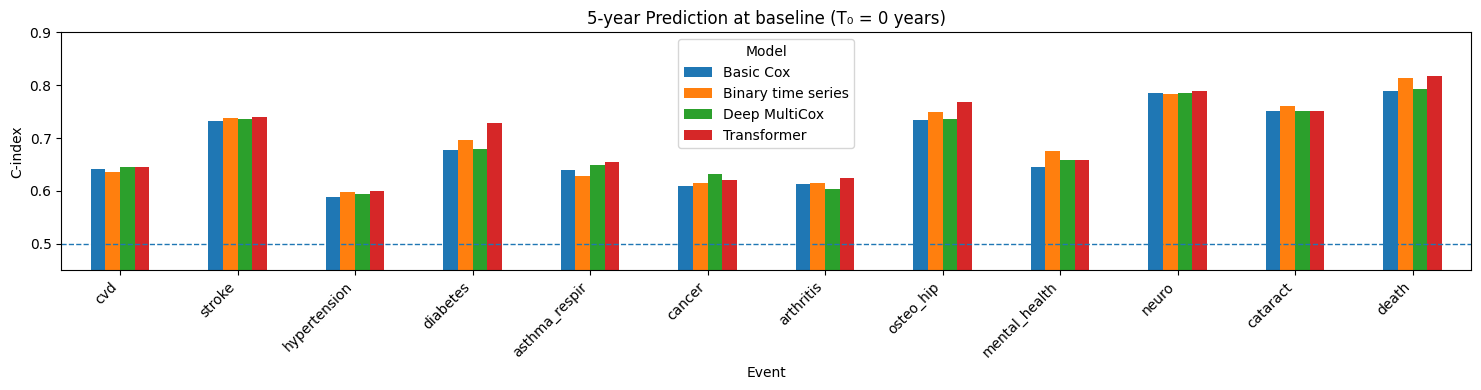

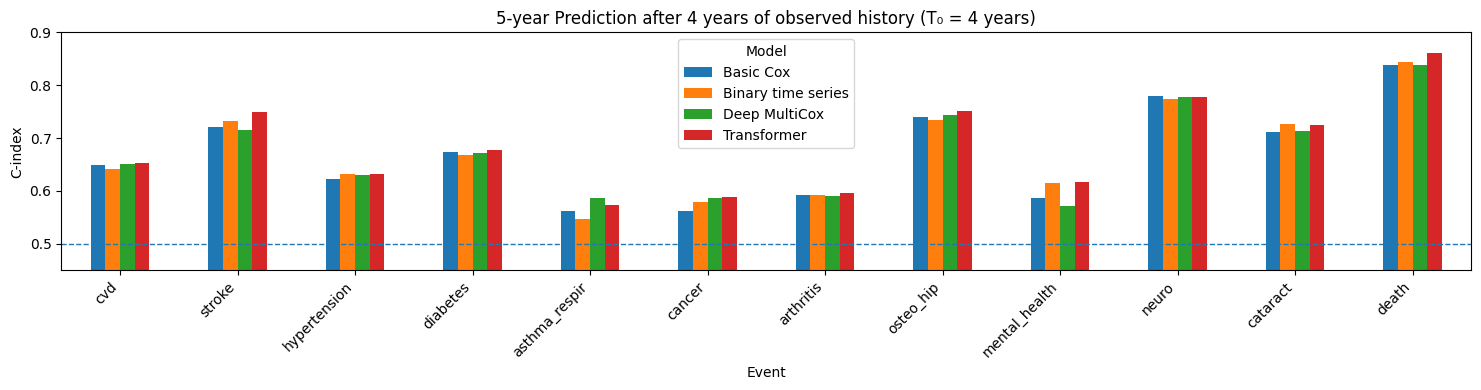

In [30]:
import matplotlib.pyplot as plt
plot_cols = [    "Basic Cox",    "Binary time series",    "Deep MultiCox",    "Transformer",]
ax = cindex_t0_6y[plot_cols].plot(    kind="bar",    figsize=(15, 4),)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_ylim(0.45, 0.90); ax.set_ylabel("C-index"); ax.set_xlabel("Event")
ax.set_title(    "5-year Prediction at baseline (T₀ = 0 years)")
plt.xticks(rotation=45, ha="right"); plt.legend(title="Model"); plt.tight_layout()
plt.show()

ax = cindex_t4_6y[plot_cols].plot(    kind="bar",    figsize=(15, 4),)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.set_ylim(0.45, 0.90); ax.set_ylabel("C-index"); ax.set_xlabel("Event")
ax.set_title(    "5-year Prediction after 4 years of observed history (T₀ = 4 years)")
plt.xticks(rotation=45, ha="right"); plt.legend(title="Model"); plt.tight_layout()
plt.show()

## ANALYSES

In [152]:
import importlib
import elsa_analysis
importlib.reload(elsa_analysis)

from elsa_analysis import (
    landmark_frame, rollout_transformer, rollout_binary,
    calibration_table, calibration_slope, calibration_metrics,
    plot_calibration_grid, order_events_by_slope,
    cindex_progression, plot_cindex_progression,
    observed_phi, model_phi, phi_matched, plot_phi_grid,
    influence_matrix, plot_influence,
)
print([f for f in ("phi_matched", "calibration_slope", "order_events_by_slope")
       if hasattr(elsa_analysis, f)])

['phi_matched', 'calibration_slope', 'order_events_by_slope']


### 1) Calibration at T0 = 4, horizon 6 years

In [129]:
T0, H = 4.0, 10.0
L, NSTEP = int(T0 / INTERVAL_YEARS), int(H / INTERVAL_YEARS)   # 2, 3
ids = test_wide["id"].to_numpy()

In [154]:
# --- Basic Cox: conditional survival, exact from lifelines ---
def cox_risk(e):
    d = test_wide[COVARIATE_COLS]
    sf = cox_models[e].predict_survival_function(d, times=[T0, T0 + H])
    s0, s1 = sf.iloc[0].to_numpy(), sf.iloc[1].to_numpy()
    return 1.0 - s1 / np.clip(s0, 1e-12, None)

# --- Deep MultiCox: needs a Breslow baseline (lifelines does this for you) ---
def breslow_risk(k, e):
    eta_tr = score_multicox_nn(multicox_model, multicox_scaler,
                               train_wide, COVARIATE_COLS)[:, k]
    el = train_wide[f"prevalent_{e}"].to_numpy() == 0
    t, d = train_wide[f"time_{e}"].to_numpy(), train_wide[f"event_{e}"].to_numpy()
    o = np.argsort(t[el]); tt, dd, ee = t[el][o], d[el][o], eta_tr[el][o]
    risk = np.cumsum(np.exp(ee)[::-1])[::-1]
    H0 = np.cumsum(dd / np.clip(risk, 1e-12, None))
    eta_te = score_multicox_nn(multicox_model, multicox_scaler,
                               test_wide, COVARIATE_COLS)[:, k]
    h0 = lambda u: np.interp(u, tt, H0)
    return 1.0 - np.exp(-(h0(T0 + H) - h0(T0)) * np.exp(eta_te))

# --- Binary TS: no feedback, so the hazards multiply out deterministically ---
@torch.no_grad()
def binary_risk():
    dbin = test_long_binary.sort_values(["id", "interval"]).reset_index(drop=True)
    T = dbin["interval"].nunique()
    F = dbin[binary_features].to_numpy(np.float32).reshape(len(ids), T, -1)
    surv = np.ones((len(ids), len(EVENT_TYPES)))
    for step in range(NSTEP):
        t = min(L + step, T - 1)
        x = torch.tensor(binary_scaler.transform(F[:, t, :]), dtype=torch.float32)
        it = torch.full((len(ids),), t, dtype=torch.long)
        surv *= (1 - torch.sigmoid(binary_model(x, it)).numpy())
    return 1 - surv


CITL  slope    ICI
              model                                  
cvd           Basic Cox           0.014  1.188  0.030
              Binary time series  0.044  1.078  0.044
              Deep MultiCox       0.016  1.259  0.031
              Transformer         0.057  1.066  0.057
stroke        Basic Cox          -0.015  0.678  0.015
              Binary time series -0.004  1.005  0.012
              Deep MultiCox      -0.015  0.657  0.020
              Transformer         0.001  0.899  0.016
hypertension  Basic Cox          -0.004  0.731  0.035
              Binary time series  0.038  1.281  0.038
              Deep MultiCox      -0.004  0.783  0.016
              Transformer         0.041  0.758  0.042
diabetes      Basic Cox          -0.010  0.967  0.010
              Binary time series  0.004  0.755  0.017
              Deep MultiCox      -0.012  0.827  0.014
              Transformer         0.000  0.749  0.017
asthma_respir Basic Cox           0.014  1.009  0.018
              Binary time series  0.024  0.820  0.024
              Deep MultiCox       0.015  1.138  0.015
              Transformer         0.029  0.753  0.029
cancer        Basic Cox          -0.008  0.518  0.021
              Binary time series  0.013  1.023  0.014
              Deep MultiCox      -0.006  0.749  0.013
              Transformer         0.014  0.669  0.020
arthritis     Basic Cox          -0.013  0.844  0.020
              Binary time series  0.014  0.995  0.015
              Deep MultiCox      -0.013  0.827  0.022
              Transformer         0.007  0.722  0.026
osteo_hip     Basic Cox          -0.012  0.801  0.025
              Binary time series  0.000  0.791  0.017
              Deep MultiCox      -0.013  0.840  0.024
              Transformer         0.012  0.997  0.017
mental_health Basic Cox           0.001  0.650  0.008
              Binary time series  0.005  0.522  0.009
              Deep MultiCox       0.001  0.556  0.007
              Transformer         0.002  0.554  0.009
neuro         Basic Cox          -0.004  0.620  0.009
              Binary time series  0.002  0.883  0.005
              Deep MultiCox      -0.004  0.635  0.010
              Transformer         0.007  0.862  0.007
cataract      Basic Cox          -0.017  0.982  0.053
              Binary time series  0.027  1.085  0.035
              Deep MultiCox      -0.019  0.990  0.032
              Transformer         0.045  1.325  0.052
death         Basic Cox          -0.000  1.100  0.014
              Binary time series  0.009  1.124  0.023
              Deep MultiCox      -0.003  1.061  0.015
              Transformer         0.025  1.299  0.027

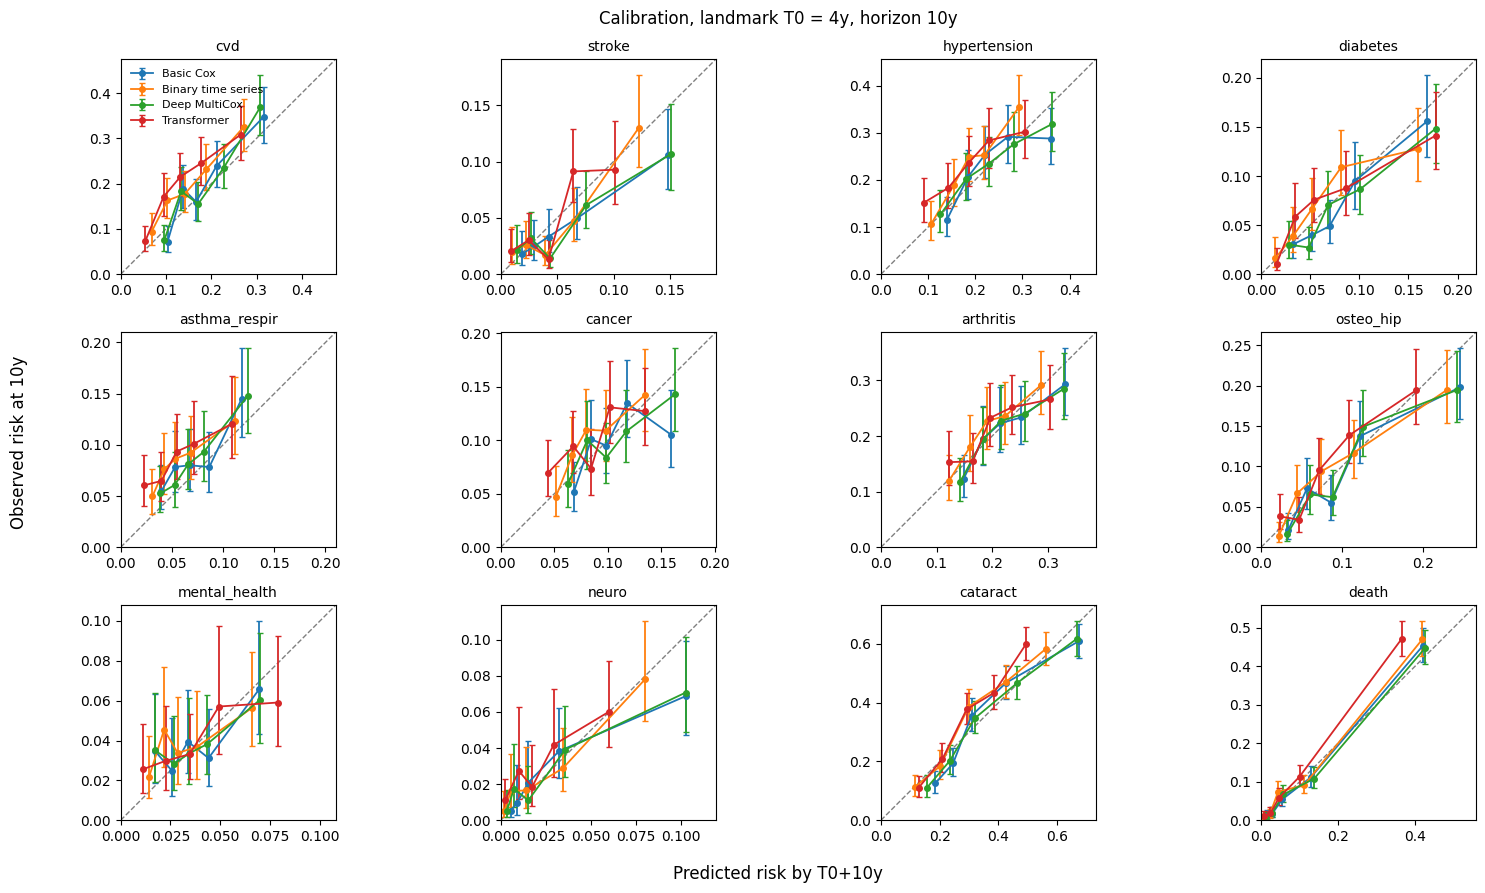

In [156]:
# --- Transformer: history feeds back, so Monte Carlo ---
ever_tr, tr_ids = rollout_transformer(
    transformer_model, test_long_tr, transformer_features, EVENT_TYPES,
    landmark_interval=L, n_steps=NSTEP, interval_years=INTERVAL_YEARS,
    n_sims=200, ids=ids, seed=SEED)

bin_p = binary_risk()
tabs = {}
for k, e in enumerate(EVENT_TYPES):
    preds = {"Basic Cox": cox_risk(e),
             "Deep MultiCox": breslow_risk(k, e),
             "Binary time series": bin_p[:, k],
             "Transformer": ever_tr[:, :, k].mean(1)}
    tabs[e] = calibration_table(test_wide, preds, e, T0, H, n_bins=5)

plot_calibration_grid(tabs, T0, H)
pd.concat({e: calibration_metrics(t) for e, t in tabs.items()}).round(3)

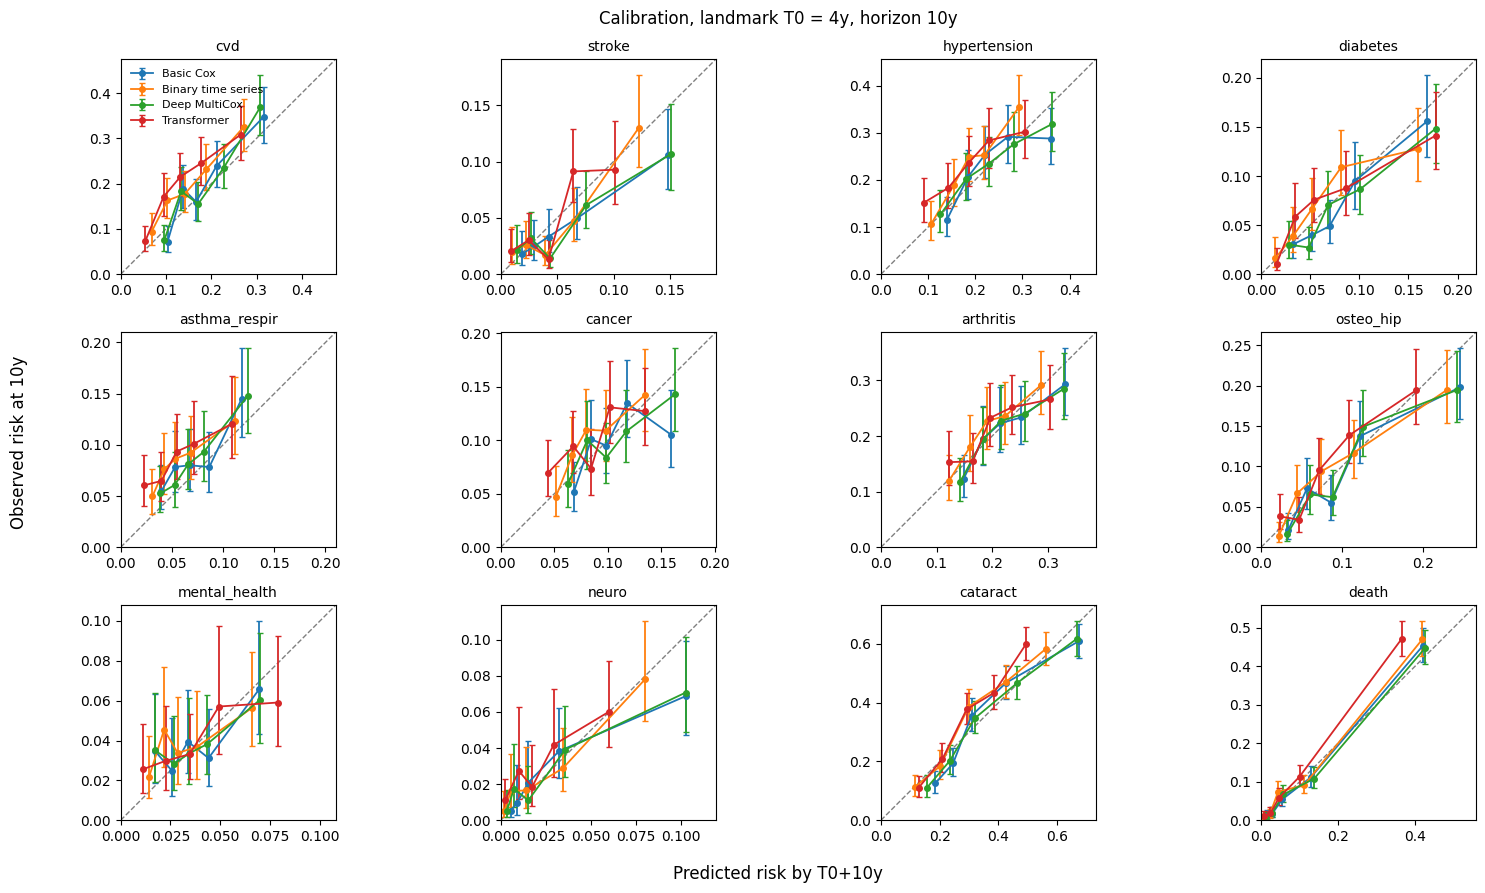

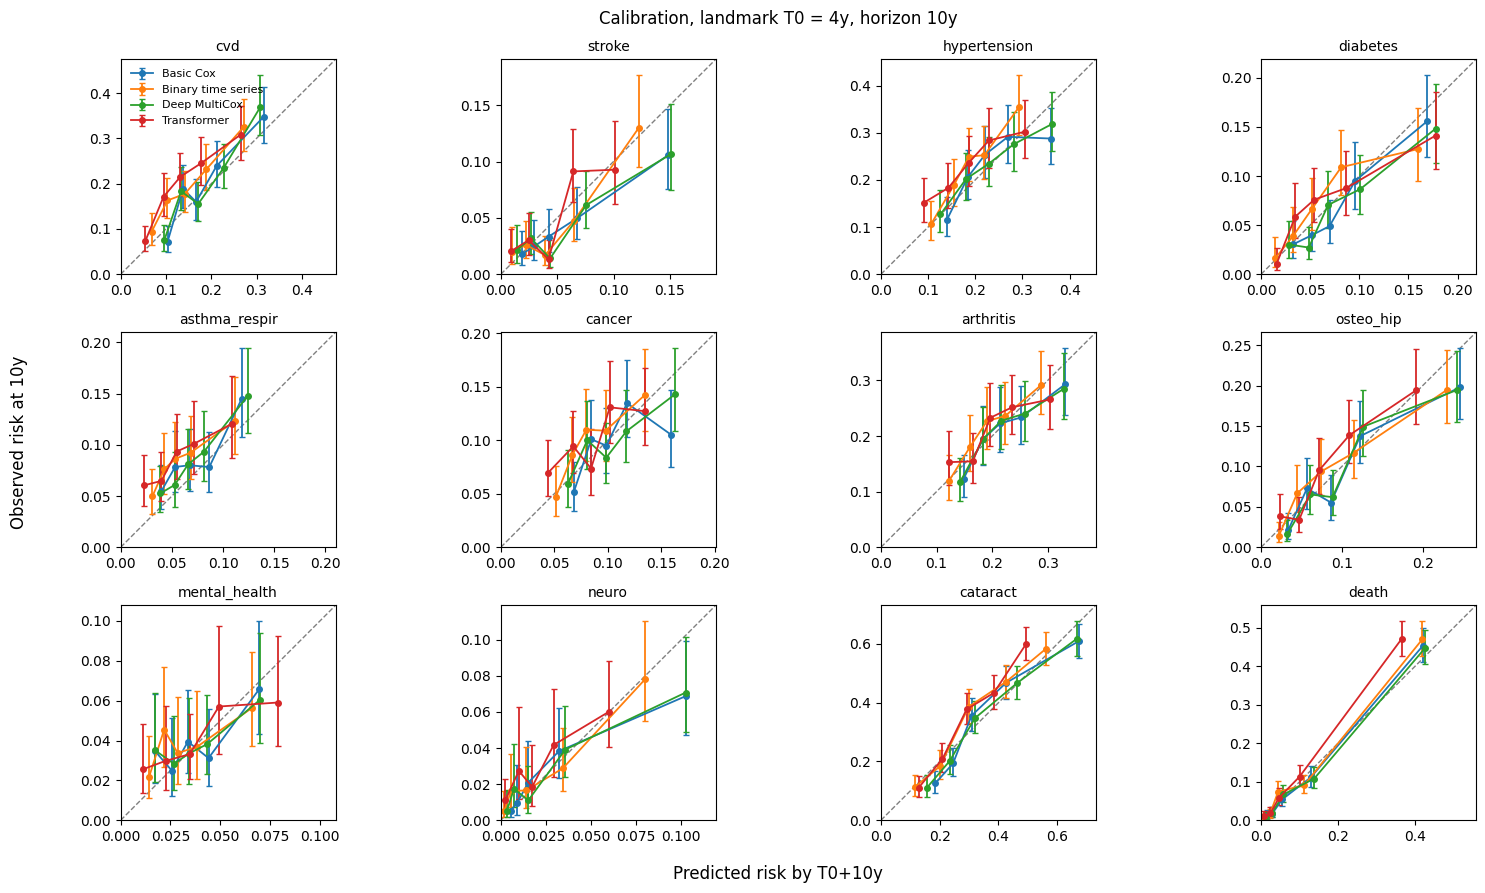

In [157]:
plot_calibration_grid(tabs, T0, H)


### 2) Progression with available history 

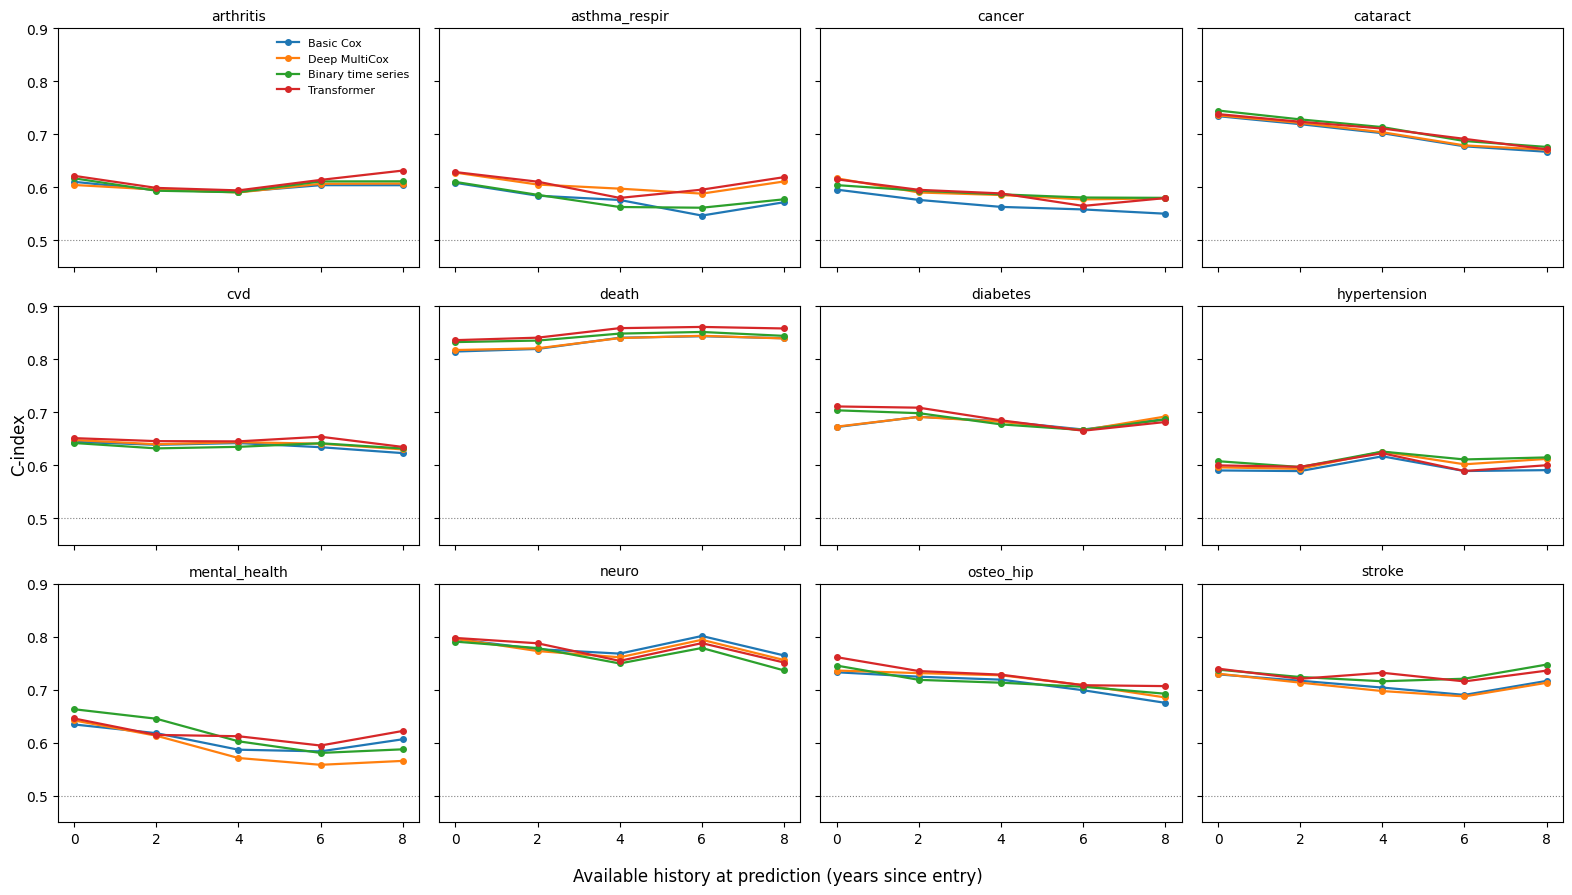

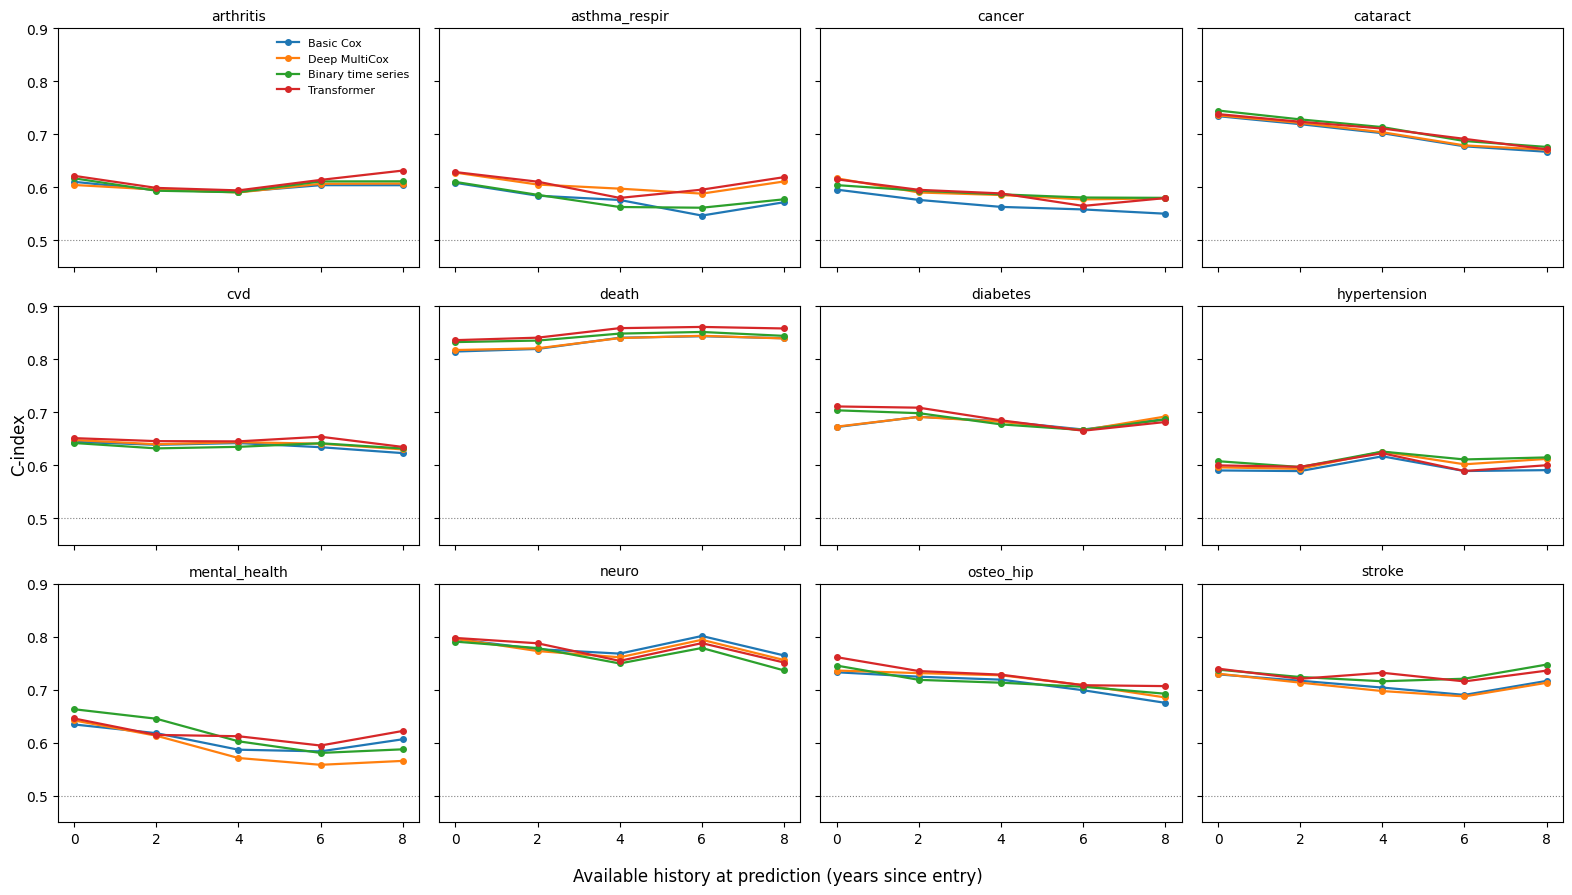

In [115]:
@torch.no_grad()
def eta_binary(lm):
    dbin = test_long_binary.sort_values(["id","interval"]).reset_index(drop=True)
    row = dbin[dbin.interval == int(lm / INTERVAL_YEARS)].set_index("id")
    x = torch.tensor(binary_scaler.transform(
        row.loc[ids, binary_features].to_numpy(np.float32)), dtype=torch.float32)
    return binary_model.get_eta(x).numpy()

@torch.no_grad()
def eta_transformer(lm):
    li = int(lm / INTERVAL_YEARS)
    df = test_long_tr.sort_values(["id","interval"]).reset_index(drop=True)
    T = df["interval"].nunique()
    X = torch.tensor(df[transformer_features].to_numpy(np.float32)).view(
        len(ids), T, len(transformer_features))
    return transformer_model.get_eta(X[:, :li + 1, :])[:, li, :].numpy()

cox_s = np.column_stack([
    np.log(cox_models[e].predict_partial_hazard(test_wide[COVARIATE_COLS]))
    for e in EVENT_TYPES])
mc_s = score_multicox_nn(multicox_model, multicox_scaler, test_wide, COVARIATE_COLS)

prog = cindex_progression(
    test_wide,
    {"Basic Cox": lambda lm: cox_s,
     "Deep MultiCox": lambda lm: mc_s,
     "Binary time series": eta_binary,
     "Transformer": eta_transformer},
    EVENT_TYPES, landmarks=[0, 2, 4, 6, 8], horizon=H)

plot_cindex_progression(prog, ["Basic Cox", "Deep MultiCox",
                               "Binary time series", "Transformer"])

In [40]:
obs_p = {e: landmark_frame(test_wide, e, 0.0, 6.0)["occ"].mean() for e in EVENT_TYPES}
mod_p = dict(zip(EVENT_TYPES, ever_tr.reshape(-1, len(EVENT_TYPES)).mean(0)))
pd.DataFrame({"observed": obs_p, "model": mod_p}).round(4)

,observed,model
cvd,0.0774,0.0693
stroke,0.0235,0.0240
hypertension,0.1181,0.1173
diabetes,0.0394,0.0434
asthma_respir,0.0381,0.0409
cancer,0.0444,0.0385
arthritis,0.0848,0.1015
osteo_hip,0.0373,0.0439
mental_health,0.0333,0.0475
neuro,0.0172,0.0147


### 3) Pair-wise correlations at T0 = 0 and 4

T0=0: pairs retained, n = 1070-1947
T0=4: pairs retained, n = 484-1068


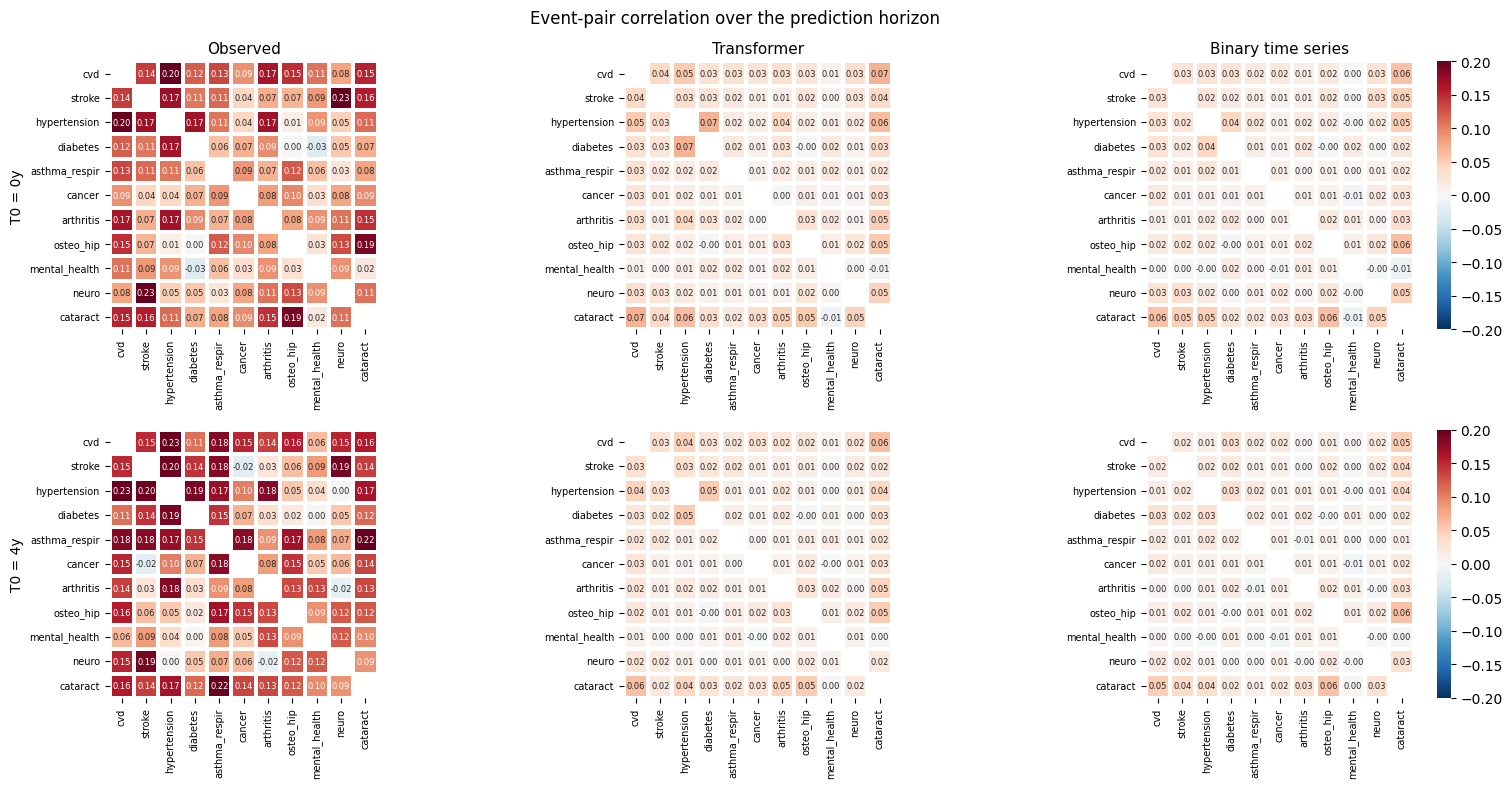

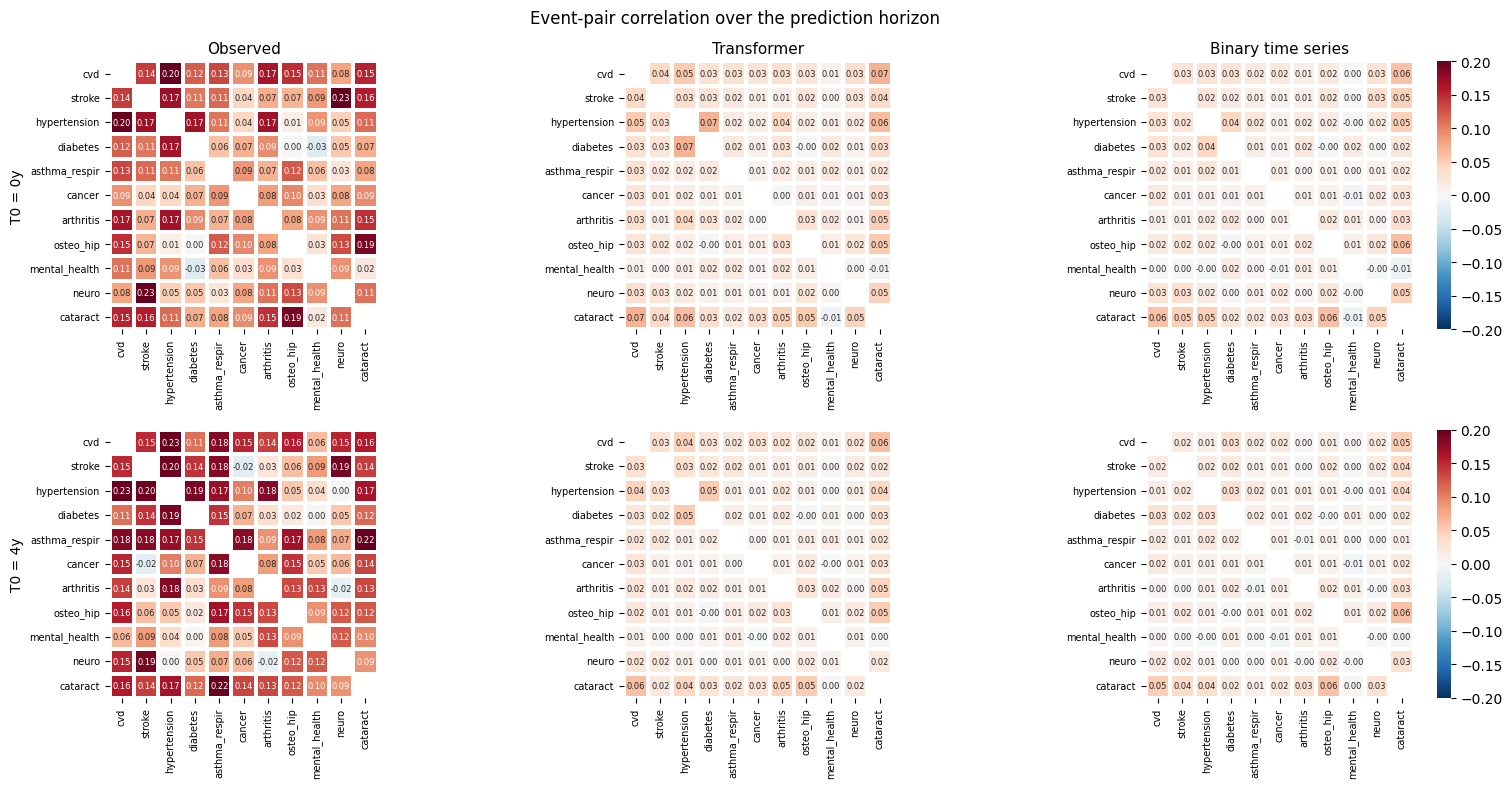

In [158]:
H = 10.0
NSTEP = int(H / INTERVAL_YEARS)      # 5

mats = {}
for lm in [0.0, 4.0]:
    li = int(lm / INTERVAL_YEARS)

    ev_tr, tr_ids = rollout_transformer(
        transformer_model, test_long_tr, transformer_features, EVENT_TYPES,
        li, NSTEP, INTERVAL_YEARS, n_sims=100, ids=ids, seed=SEED)
    Mo, Mm, N = phi_matched(test_wide, ev_tr, EVENT_TYPES, lm, H,
                            ids=tr_ids, report_n=True)      # death dropped
    mats[(lm, "Observed")]    = Mo
    mats[(lm, "Transformer")] = Mm
    print(f"T0={lm:g}: pairs retained, n = {np.nanmin(N.values):.0f}"
          f"-{np.nanmax(N.values):.0f}")

    ev_bn, bn_ids = rollout_binary(
        binary_model, binary_scaler, test_long_binary, binary_features,
        EVENT_TYPES, li, NSTEP, INTERVAL_YEARS, n_sims=100, ids=ids, seed=SEED)
    _, Mb = phi_matched(test_wide, ev_bn, EVENT_TYPES, lm, H, ids=bn_ids)
    mats[(lm, "Binary time series")] = Mb

plot_phi_grid(mats, [0.0, 4.0], [e for e in EVENT_TYPES if e != "death"],
              vmax=0.2)

### 4) Δ log-odds, T0 = 4 → T1 = 10

neuro          mental_health    0.981826
               osteo_hip        0.604038
hypertension   diabetes         0.590189
asthma_respir  mental_health    0.492752
stroke         asthma_respir    0.447034
cvd            stroke           0.446501
arthritis      osteo_hip        0.406474
mental_health  asthma_respir    0.402458
               diabetes         0.387506
asthma_respir  osteo_hip        0.374498
cvd            asthma_respir    0.350194
cataract       mental_health    0.343313
hypertension   cvd              0.336950
arthritis      cvd              0.327215
cvd            diabetes         0.326692
dtype: float64

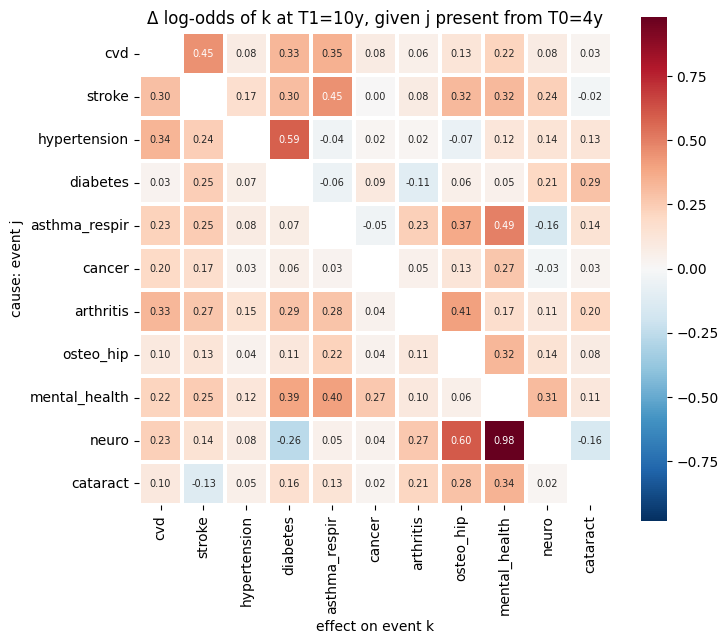

In [162]:
M = influence_matrix(transformer_model, test_long_tr, transformer_features,
                     EVENT_TYPES, s=2, t=5, ids=ids)      # 4y -> 10y
plot_influence(M, title="Δ log-odds of k at T1=10y, given j present from T0=4y")

M.stack().sort_values(ascending=False).head(15)